### resource : https://youtu.be/tL5puCeDr-o?si=HeUxSMLNmZ7sB5Kt

Epoch: 0, Loss: 0.5372219681739807


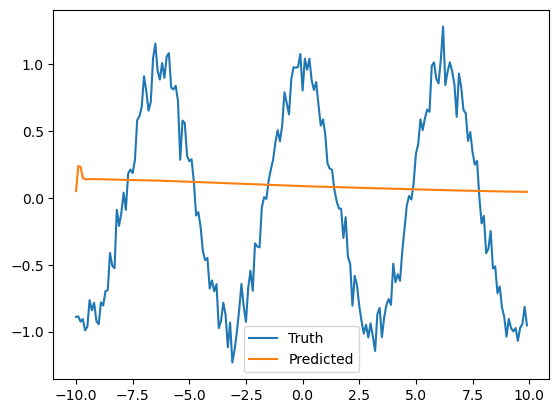

Epoch: 500, Loss: 0.00982860941439867


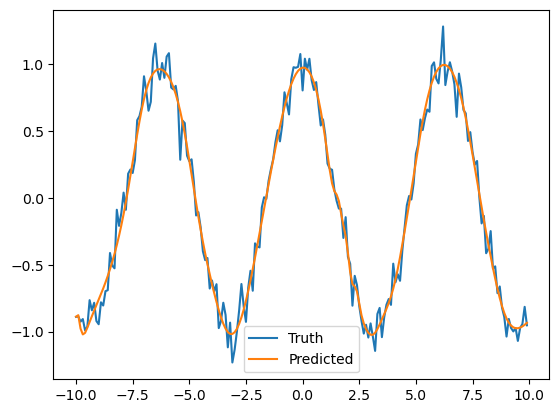

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Data preparation
X_t = np.arange(-10, 10, 0.1).reshape(-1, 1)
Y_t = np.cos(X_t) + 0.1 * np.random.randn(X_t.shape[0], 1)

X_t = torch.from_numpy(X_t).float()
Y_t = torch.from_numpy(Y_t).float()

# Model definition
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out)
        return out

# Hyperparameters
input_size = 1
hidden_size = 100
output_size = 1
model = RNNModel(input_size, hidden_size, output_size)

# Loss and Optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)

# Training loop
n_epochs = 1000
for epoch in range(n_epochs+1):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_t.unsqueeze(0)) 
    loss = criterion(outputs.squeeze(0), Y_t)
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f'Epoch: {epoch}, Loss: {loss.item()}')
        plt.plot(X_t.numpy(), Y_t.numpy(), label='Truth')
        plt.plot(X_t.numpy(), outputs.data.numpy().reshape(-1, 1), label='Predicted')
        plt.legend()
        plt.show()



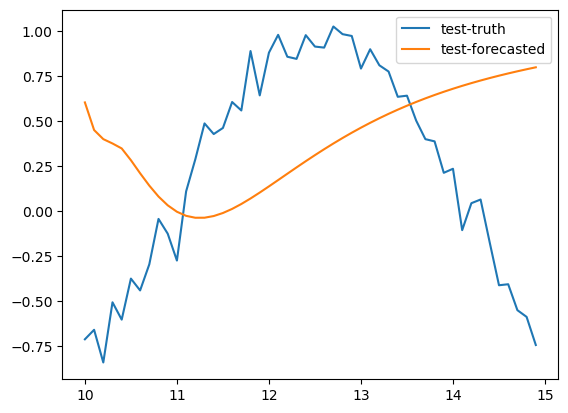

In [3]:
# predict the test data
X_test = np.arange(10,15,0.1).reshape(-1,1)
Y_test = np.cos(X_test) + 0.1*np.random.randn(X_test.shape[0],1)

y_pred = model(torch.from_numpy(X_test).float().unsqueeze(0)).squeeze(0).detach().numpy()
# plot Y_test vs y_pred
plt.plot(X_test,Y_test)
plt.plot(X_test,y_pred)

plt.legend(["test-truth","test-forecasted"])

### so far, we assumed that X_t will provide information about Y and havent used the previous Y_t's as feature. lets implement this and compare its affect on  generalization ability